<a href="https://colab.research.google.com/github/ashnaali330-star/FSA_RAG_Chatbot/blob/main/hotel_booking_hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv("/content/hotel_bookings.csv")


In [6]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
remove_cols = [
    'reservation_status',
    'reservation_status_date',
    'assigned_room_type',
    'booking_changes'
]

df = df.drop(columns=remove_cols)

In [9]:

df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,C,No Deposit,NaN,NaN,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,C,No Deposit,NaN,NaN,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,A,No Deposit,NaN,NaN,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,A,No Deposit,304.0,NaN,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,A,No Deposit,240.0,NaN,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,A,No Deposit,394.0,NaN,0,Transient,96.14,0,0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,E,No Deposit,9.0,NaN,0,Transient,225.43,0,2
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,D,No Deposit,9.0,NaN,0,Transient,157.71,0,4
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,A,No Deposit,89.0,NaN,0,Transient,104.40,0,0


In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [12]:
int_cols = [
    'agent',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'children',
    'company'
]

df[int_cols] = df[int_cols].astype('Int64')

In [13]:

df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,C,No Deposit,<NA>,<NA>,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,C,No Deposit,<NA>,<NA>,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,A,No Deposit,<NA>,<NA>,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,A,No Deposit,304,<NA>,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,A,No Deposit,240,<NA>,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,A,No Deposit,394,<NA>,0,Transient,96.14,0,0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,E,No Deposit,9,<NA>,0,Transient,225.43,0,2
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,D,No Deposit,9,<NA>,0,Transient,157.71,0,4
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,A,No Deposit,89,<NA>,0,Transient,104.40,0,0


In [14]:

df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [15]:

# Fill categorical columns
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(df['agent'].mode()[0])
df['company'] = df['company'].fillna(df['company'].mode()[0])
df['customer_type'] = df['customer_type'].fillna(df['customer_type'].mode()[0])

# Fill numerical columns with median
num_cols = [
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    "children"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [16]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [17]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Remove target column
num_cols = num_cols.drop('is_canceled')

print(num_cols)

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')


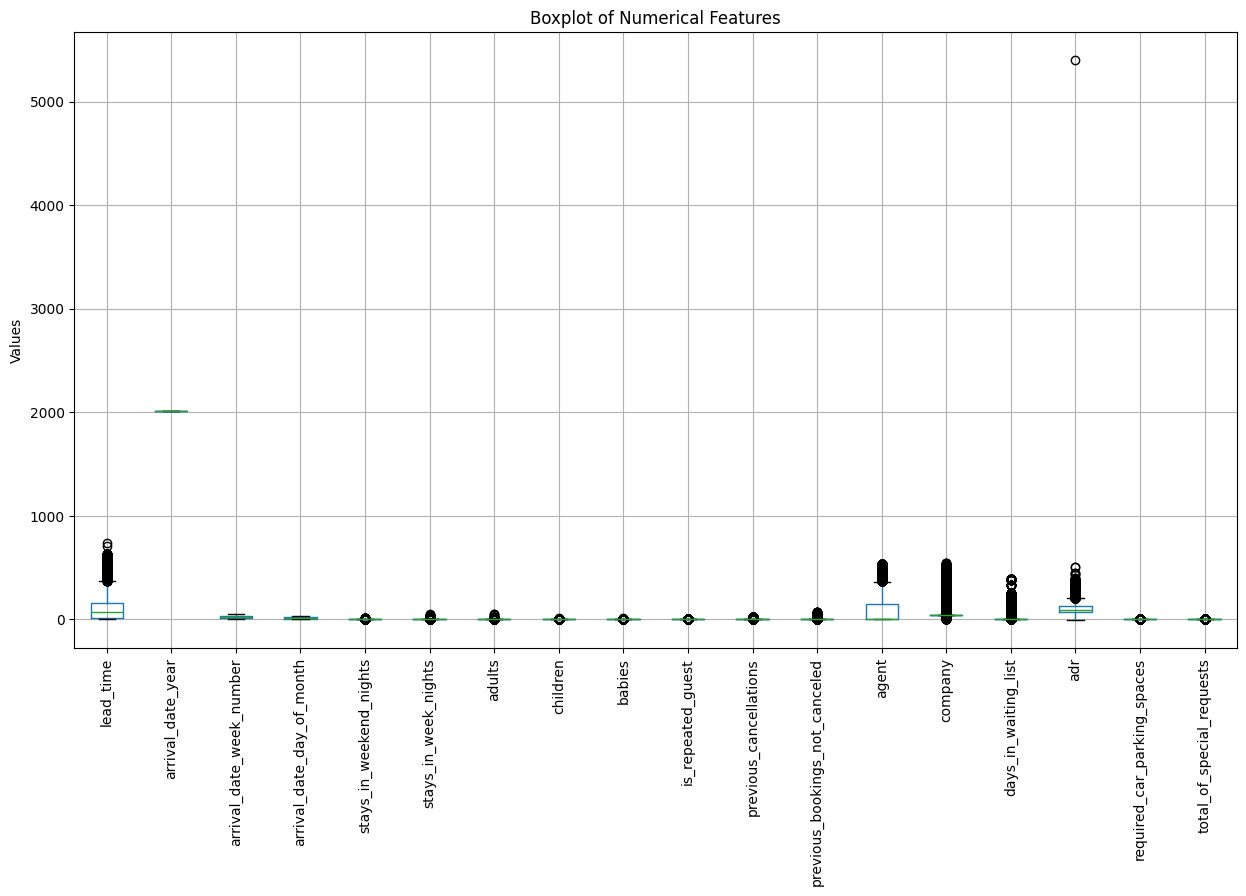

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

df[num_cols].boxplot()

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [19]:
outlier_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adr'
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(109429, 28)


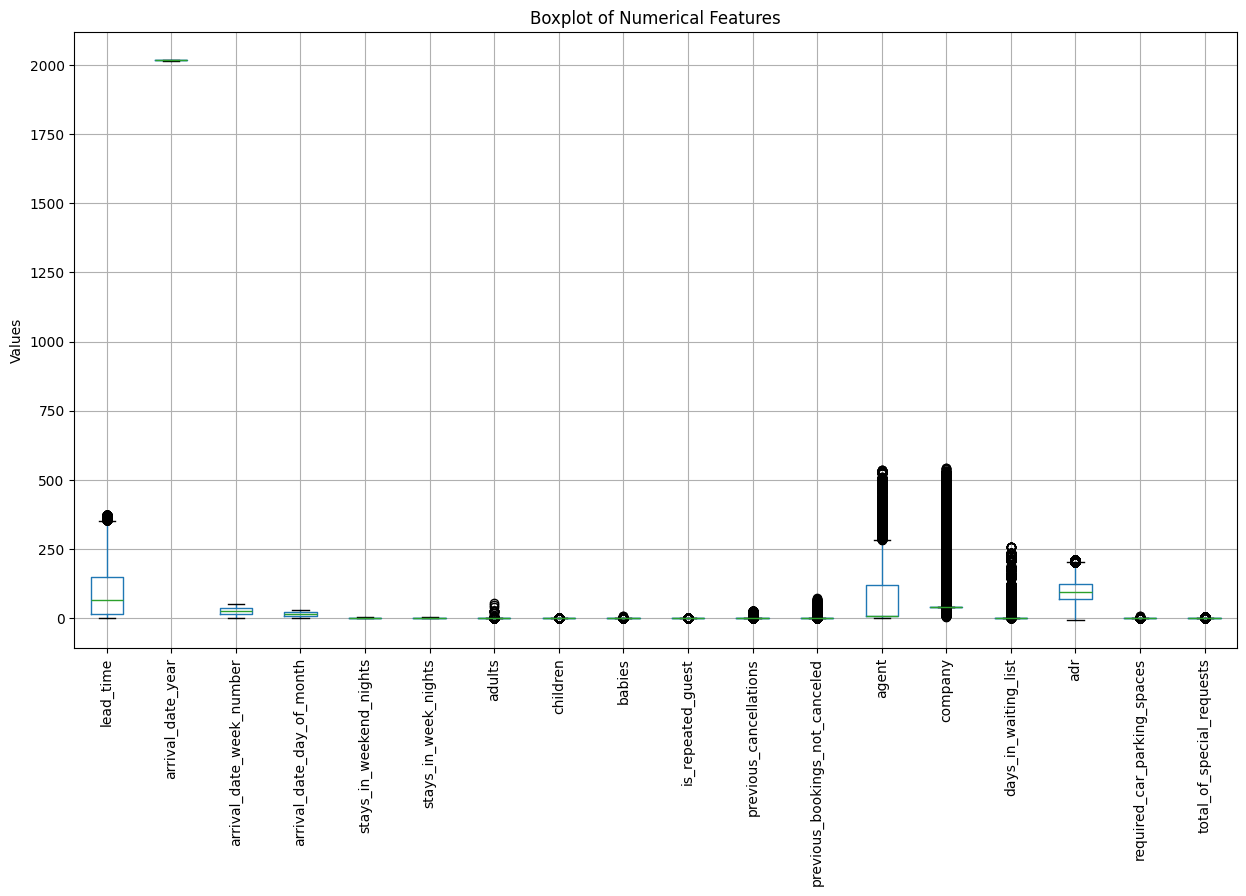

In [20]:

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

df[num_cols].boxplot()

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [21]:

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [22]:


print("X shape:", X.shape)
print("y shape:", y.shape)

print(X.columns)
print(y.head())

X shape: (109429, 27)
y shape: (109429,)
Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type',
       'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')
0    0
2    0
3    0
4    0
5    0
Name: is_canceled, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore")

In [25]:


X_train

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
68907,City Hotel,114,2017,May,21,22,1,2,2,0,...,0,A,No Deposit,9,40,0,Transient,117.00,0,0
82501,City Hotel,0,2016,November,48,23,0,4,1,0,...,5,A,No Deposit,9,163,0,Transient,50.00,0,2
109195,City Hotel,59,2017,April,14,2,2,4,2,0,...,0,D,No Deposit,9,40,0,Transient,126.00,0,3
2395,Resort Hotel,1,2015,October,42,11,2,0,2,0,...,0,A,No Deposit,240,40,0,Transient,56.40,1,0
119105,City Hotel,14,2017,August,34,24,2,3,2,0,...,0,A,No Deposit,9,40,0,Transient,125.60,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61765,City Hotel,167,2016,December,53,26,1,3,2,0,...,0,D,No Deposit,9,40,0,Transient,97.75,0,0
85101,City Hotel,1,2016,March,11,8,0,2,2,0,...,0,A,No Deposit,9,40,0,Transient-Party,103.00,0,0
112715,City Hotel,136,2017,May,21,24,0,4,2,0,...,0,D,No Deposit,9,40,0,Transient,139.50,0,0
976,Resort Hotel,54,2015,August,32,8,2,5,2,0,...,0,D,No Deposit,240,40,0,Transient,205.00,0,1


In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87543 entries, 68907 to 18489
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87543 non-null  object 
 1   lead_time                       87543 non-null  int64  
 2   arrival_date_year               87543 non-null  int64  
 3   arrival_date_month              87543 non-null  object 
 4   arrival_date_week_number        87543 non-null  int64  
 5   arrival_date_day_of_month       87543 non-null  int64  
 6   stays_in_weekend_nights         87543 non-null  int64  
 7   stays_in_week_nights            87543 non-null  int64  
 8   adults                          87543 non-null  int64  
 9   children                        87543 non-null  Int64  
 10  babies                          87543 non-null  int64  
 11  meal                            87543 non-null  object 
 12  country                         8

In [27]:
ohe.fit(X[['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type', 'company',
       'customer_type']])

OneHotEncoder(handle_unknown='ignore')

In [28]:

from sklearn.compose import make_column_transformer

column_trans = make_column_transformer((OneHotEncoder(categories=ohe.categories_, handle_unknown='ignore'),['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type', 'company',
       'customer_type']),remainder='passthrough')

In [29]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

from sklearn.pipeline import make_pipeline
pipe_lr = make_pipeline(column_trans,lr)

In [30]:
pipe_lr.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['City Hotel', 'Resort Hotel'], dtype=object),
                                                                            array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object),
                                                                            array(['BB', 'FB', 'HB', 'SC', 'Undefi...
       511., 512., 513., 514., 515., 516., 518., 520., 521., 523., 525.,
       528., 530., 531., 534., 539., 541., 543.]),
                                                                            array(['Contract', 'Group', 'Transient', 'Transient-Party'], dtype=object)],
                                                                handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'deposit_type', 'company',
                                                   'customer_type'])])),
                ('logisticregression', LogisticRegression())])

In [31]:
y_pred_lr = pipe_lr.predict(X_test)

In [32]:
y_pred_lr = pipe_lr.predict(X_test)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84     13808
           1       0.78      0.56      0.65      8078

    accuracy                           0.78     21886
   macro avg       0.78      0.73      0.74     21886
weighted avg       0.78      0.78      0.77     21886



In [34]:
from sklearn.tree import DecisionTreeClassifier
dtr = DecisionTreeClassifier(random_state=4231)
from sklearn.pipeline import make_pipeline
pipe_dt = make_pipeline(column_trans,dtr)

In [35]:
pipe_dt.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['City Hotel', 'Resort Hotel'], dtype=object),
                                                                            array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object),
                                                                            array(['BB', 'FB', 'HB', 'SC', 'Undefi...
       528., 530., 531., 534., 539., 541., 543.]),
                                                                            array(['Contract', 'Group', 'Transient', 'Transient-Party'], dtype=object)],
                                                                handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'deposit_type', 'company',
                                                   'customer_type'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=4231))])

In [36]:
y_pred_dt = pipe_dt.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89     13808
           1       0.81      0.81      0.81      8078

    accuracy                           0.86     21886
   macro avg       0.85      0.85      0.85     21886
weighted avg       0.86      0.86      0.86     21886



In [38]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

from sklearn.pipeline import make_pipeline
pipe_rf = make_pipeline(column_trans,rf)

In [39]:
pipe_rf.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['City Hotel', 'Resort Hotel'], dtype=object),
                                                                            array(['April', 'August', 'December', 'February', 'January', 'July',
       'June', 'March', 'May', 'November', 'October', 'September'],
      dtype=object),
                                                                            array(['BB', 'FB', 'HB', 'SC', 'Undefi...
       511., 512., 513., 514., 515., 516., 518., 520., 521., 523., 525.,
       528., 530., 531., 534., 539., 541., 543.]),
                                                                            array(['Contract', 'Group', 'Transient', 'Transient-Party'], dtype=object)],
                                                                handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'deposit_type', 'company',
                                                   'customer_type'])])),
                ('randomforestclassifier', RandomForestClassifier())])

In [40]:
y_pred_rf = pipe_rf.predict(X_test)

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     13808
           1       0.90      0.79      0.84      8078

    accuracy                           0.89     21886
   macro avg       0.89      0.87      0.88     21886
weighted avg       0.89      0.89      0.89     21886



In [42]:
from xgboost import XGBClassifier
xgbc=XGBClassifier()

from sklearn.pipeline import make_pipeline
pipe_xgbc=make_pipeline(column_trans,xgbc)

pipe_xgbc.fit(X_train,y_train)
y_pred_xgbc=pipe_xgbc.predict(X_test)


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgbc))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90     13808
           1       0.85      0.79      0.82      8078

    accuracy                           0.87     21886
   macro avg       0.87      0.85      0.86     21886
weighted avg       0.87      0.87      0.87     21886



In [44]:
X_train["meal"]

,meal
68907,SC
82501,BB
109195,BB
2395,BB
119105,SC
...,...
61765,BB
85101,BB
112715,BB
976,HB


In [45]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 87543 entries, 68907 to 18489
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87543 non-null  object 
 1   lead_time                       87543 non-null  int64  
 2   arrival_date_year               87543 non-null  int64  
 3   arrival_date_month              87543 non-null  object 
 4   arrival_date_week_number        87543 non-null  int64  
 5   arrival_date_day_of_month       87543 non-null  int64  
 6   stays_in_weekend_nights         87543 non-null  int64  
 7   stays_in_week_nights            87543 non-null  int64  
 8   adults                          87543 non-null  int64  
 9   children                        87543 non-null  Int64  
 10  babies                          87543 non-null  int64  
 11  meal                            87543 non-null  object 
 12  country                         8

In [46]:
import gradio as gr
import pandas as pd

def predict_cancellation(
    hotel, lead_time, arrival_date_year, arrival_date_month, arrival_date_week_number,
    arrival_date_day_of_month, stays_in_weekend_nights, stays_in_week_nights, adults,
    children, babies, meal, country, market_segment, distribution_channel,
    is_repeated_guest, previous_cancellations, previous_bookings_not_canceled,
    reserved_room_type, deposit_type, agent, company, days_in_waiting_list,
    customer_type, adr, required_car_parking_spaces, total_of_special_requests
):
    # Construct input dataframe matching exact model feature names
    input_data = pd.DataFrame([{
        'hotel': hotel,
        'lead_time': int(lead_time),
        'arrival_date_year': int(arrival_date_year),
        'arrival_date_month': arrival_date_month,
        'arrival_date_week_number': int(arrival_date_week_number),
        'arrival_date_day_of_month': int(arrival_date_day_of_month),
        'stays_in_weekend_nights': int(stays_in_weekend_nights),
        'stays_in_week_nights': int(stays_in_week_nights),
        'adults': int(adults),
        'children': int(children),
        'babies': int(babies),
        'meal': meal,
        'country': country,
        'market_segment': market_segment,
        'distribution_channel': distribution_channel,
        'is_repeated_guest': 1 if is_repeated_guest == "Yes" else 0,
        'previous_cancellations': int(previous_cancellations),
        'previous_bookings_not_canceled': int(previous_bookings_not_canceled),
        'reserved_room_type': reserved_room_type,
        'deposit_type': deposit_type,
        'agent': float(agent),
        'company': float(company),
        'days_in_waiting_list': int(days_in_waiting_list),
        'customer_type': customer_type,
        'adr': float(adr),
        'required_car_parking_spaces': int(required_car_parking_spaces),
        'total_of_special_requests': int(total_of_special_requests)
    }])

    # Model inference
    prediction = pipe_rf.predict(input_data)[0]
    probability = pipe_rf.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = "⚠️ HIGH RISK: Booking is likely to be CANCELLED"
    else:
        result = "✅ LOW RISK: Booking is likely to NOT be cancelled"

    return f"{result}\nCancellation Probability: {probability * 100:.2f}%"


# Build the UI using gr.Blocks for flexible layout
with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky")) as app:
    gr.Markdown(
        """
        # 🏨 Hotel Booking Cancellation Predictor
        Enter booking details to predict cancellation risk and probability.
        """
    )

    with gr.Row():
        # Input Section (Left)
        with gr.Column(scale=2):
            with gr.Accordion("🏨 1. Booking Details", open=True):
                hotel = gr.Dropdown(["Resort Hotel", "City Hotel"], value="City Hotel", label="Hotel")
                lead_time = gr.Number(label="Lead Time (Days)", value=30)
                arrival_date_year = gr.Number(label="Arrival Year", value=2026)
                arrival_date_month = gr.Dropdown(
                    ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"],
                    value="July", label="Arrival Month"
                )
                arrival_date_week_number = gr.Number(label="Arrival Week Number", value=27)
                arrival_date_day_of_month = gr.Number(label="Arrival Day of Month", value=15)
                stays_in_weekend_nights = gr.Number(label="Weekend Nights", value=1)
                stays_in_week_nights = gr.Number(label="Week Nights", value=2)

            with gr.Accordion("👤 2. Guest Information", open=False):
                adults = gr.Number(label="Adults", value=2)
                children = gr.Number(label="Children", value=0)
                babies = gr.Number(label="Babies", value=0)
                country = gr.Textbox(label="Country Code", value="PRT")
                customer_type = gr.Dropdown(["Transient", "Contract", "Transient-Party", "Group"], value="Transient", label="Customer Type")
                is_repeated_guest = gr.Radio(["No", "Yes"], value="No", label="Is Repeated Guest?")

            with gr.Accordion("📜 3. Booking History", open=False):
                previous_cancellations = gr.Number(label="Previous Cancellations", value=0)
                previous_bookings_not_canceled = gr.Number(label="Previous Bookings Not Canceled", value=0)

            with gr.Accordion("💼 4. Segment & Room Details", open=False):
                meal = gr.Dropdown(["BB", "FB", "HB", "SC", "Undefined"], value="BB", label="Meal Package")
                market_segment = gr.Dropdown(["Direct", "Corporate", "Online TA", "Offline TA/TO", "Complementary", "Groups"], value="Online TA", label="Market Segment")
                distribution_channel = gr.Dropdown(["Direct", "Corporate", "TA/TO", "GDS"], value="TA/TO", label="Distribution Channel")
                reserved_room_type = gr.Dropdown(["A", "B", "C", "D", "E", "F", "G", "H"], value="A", label="Reserved Room Type")
                deposit_type = gr.Dropdown(["No Deposit", "Non Refund", "Refundable"], value="No Deposit", label="Deposit Type")

            with gr.Accordion("⚙️ 5. Additional Attributes", open=False):
                agent = gr.Number(label="Agent ID", value=9)
                company = gr.Number(label="Company ID", value=0)
                days_in_waiting_list = gr.Number(label="Days in Waiting List", value=0)
                adr = gr.Number(label="Average Daily Rate (ADR)", value=100.0)
                required_car_parking_spaces = gr.Number(label="Parking Spaces Required", value=0)
                total_of_special_requests = gr.Number(label="Special Requests", value=0)

            predict_btn = gr.Button("🔮 Predict Cancellation Risk", variant="primary")

        # Output Section (Right)
        with gr.Column(scale=1):
            output_text = gr.Textbox(label="Prediction Result", lines=4, interactive=False)

    # Click Callback Binding
    predict_btn.click(
        fn=predict_cancellation,
        inputs=[
            hotel, lead_time, arrival_date_year, arrival_date_month, arrival_date_week_number,
            arrival_date_day_of_month, stays_in_weekend_nights, stays_in_week_nights, adults,
            children, babies, meal, country, market_segment, distribution_channel,
            is_repeated_guest, previous_cancellations, previous_bookings_not_canceled,
            reserved_room_type, deposit_type, agent, company, days_in_waiting_list,
            customer_type, adr, required_car_parking_spaces, total_of_special_requests
        ],
        outputs=output_text
    )

if __name__ == "__main__":
    app.launch()

/tmp/ipykernel_613/2843410942.py:56: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky")) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://34a6e15835694c263f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
